# Гипотеза H2. Асимметрия негативных и позитивных новостей

## Блок 1. Импорт библиотек и параметры

In [10]:
import os
import re
import json
import math
import hashlib
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

warnings.simplefilter("default")
np.random.seed(42)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

NOTEBOOK_VERSION = "2026-03-22_v6_h6_patch"
OUTPUT_DIR = "outputs_01"
MASTER_PATH = os.path.join(OUTPUT_DIR, "returns_sentiment_enhanced.parquet")
ANALYSIS_DIR = os.path.join(OUTPUT_DIR, "analysis_03_2")
os.makedirs(ANALYSIS_DIR, exist_ok=True)

TEST_START = pd.Timestamp("2023-01-01")
ALPHA = 0.05

HORIZON_MAP = {"y1_ex": 1, "y2_ex": 2, "y3_ex": 3, "y5_ex": 5}


NEWS_FILTER_COL = "has_news_today"
USE_NEWS_ONLY_PRIMARY = True
MAIN_MODEL = "finbert_tone"
APPLY_TRAIN_WINSOR = True
WINSOR_P = 0.01


FE_MAX_ITERS = 200
FE_TOL = 1e-10


STRICT_CHECKS = True
RUN_TWFE_CHECK = True
TWFE_CHECK_MAX_ROWS = 1200
TWFE_CHECK_MAX_TICKERS = 20
TWFE_CHECK_MAX_DATES = 25


TEST_SORT_Q = 5
RUN_PERMUTATION_TEST = False
N_PERMUTATIONS = 200


USE_CACHE = True

PRIMARY_MODEL_ORDER = [
    "finbert",
    "finbert_tone",
    "finroberta",
    "distilroberta_finnews",
    "deberta_finnews",
    "twroberta",
    "vader",
    "textblob",
]

print("MASTER_PATH:", MASTER_PATH)
print("ANALYSIS_DIR:", ANALYSIS_DIR)
print("TEST_START:", TEST_START.date())
print("MAIN_MODEL:", MAIN_MODEL)
print("NOTEBOOK_VERSION:", NOTEBOOK_VERSION)

MASTER_PATH: outputs_01/returns_sentiment_enhanced.parquet
ANALYSIS_DIR: outputs_01/analysis_03_2
TEST_START: 2023-01-01
MAIN_MODEL: finbert_tone
NOTEBOOK_VERSION: 2026-03-22_v6_h6_patch


## Блок 2. Загрузка мастер-панели

В этом блоке подгружается мастер-датасет, проверяется наличие нужных столбцов и определяется набор доступных моделей тональности

In [11]:
def file_signature(path: str) -> Dict:
    st = os.stat(path)
    return {
        "path": os.path.abspath(path),
        "size_bytes": int(st.st_size),
        "mtime_utc": pd.to_datetime(st.st_mtime, unit="s", utc=True).isoformat(),
    }

if not os.path.exists(MASTER_PATH):
    raise FileNotFoundError(
        f"Master dataset not found: {MASTER_PATH}\n"
        "Run Notebook 02 first to create returns_sentiment_enhanced.parquet."
    )

MASTER_SIG = file_signature(MASTER_PATH)
MASTER_SIG.update({
    "NOTEBOOK_VERSION": NOTEBOOK_VERSION,
    "TEST_START": str(TEST_START.date()),
    "NEWS_FILTER_COL": NEWS_FILTER_COL,
    "USE_NEWS_ONLY_PRIMARY": USE_NEWS_ONLY_PRIMARY,
    "MAIN_MODEL": MAIN_MODEL,
    "APPLY_TRAIN_WINSOR": APPLY_TRAIN_WINSOR,
    "WINSOR_P": WINSOR_P,
    "FE_MAX_ITERS": FE_MAX_ITERS,
    "FE_TOL": FE_TOL,
    "TEST_SORT_Q": TEST_SORT_Q,
    "STRICT_CHECKS": STRICT_CHECKS,
})

try:
    import pyarrow.parquet as pq
    pf = pq.ParquetFile(MASTER_PATH)
    ALL_COLS = pf.schema.names
except Exception:
    tmp = pd.read_parquet(MASTER_PATH)
    ALL_COLS = list(tmp.columns)
    del tmp

required_base_cols = ["ticker", "date"] + list(HORIZON_MAP.keys())
missing_base_cols = [c for c in required_base_cols if c not in ALL_COLS]
if missing_base_cols:
    raise KeyError(f"Master parquet is missing required columns: {missing_base_cols}")

if USE_NEWS_ONLY_PRIMARY and NEWS_FILTER_COL not in ALL_COLS:
    raise KeyError(f"Column '{NEWS_FILTER_COL}' is required for the news-only sample.")

def available_primary_models(cols: List[str]) -> List[str]:
    out = []
    for m in PRIMARY_MODEL_ORDER:
        if f"{m}_score_mean" in cols:
            out.append(m)
    return out

PRIMARY_MODELS = available_primary_models(ALL_COLS)
if not PRIMARY_MODELS:
    raise ValueError("No primary sentiment models found in the master parquet.")

if MAIN_MODEL not in PRIMARY_MODELS:
    raise ValueError(
        f"Configured MAIN_MODEL='{MAIN_MODEL}' is not available. "
        f"Available models: {PRIMARY_MODELS}"
    )

BASE_COLS = [
    "ticker", "date",
    "ret_log", "mkt_ret_log", "excess_ret_log",
    "y1_ex", "y2_ex", "y3_ex", "y5_ex",
    "news_n", "has_news_today", "sector",
]
BASE_COLS = [c for c in BASE_COLS if c in ALL_COLS]

MODEL_COLS = []
for m in PRIMARY_MODELS:
    for suf in ["_score_mean", "_neg_share", "_pos_share", "_neu_share", "_news_count"]:
        c = f"{m}{suf}"
        if c in ALL_COLS:
            MODEL_COLS.append(c)

COLS_TO_LOAD = sorted(set(BASE_COLS + MODEL_COLS))
df = pd.read_parquet(MASTER_PATH, columns=COLS_TO_LOAD)

df["ticker"] = df["ticker"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
if "news_n" in df.columns:
    df["news_n"] = pd.to_numeric(df["news_n"], errors="coerce")
if "has_news_today" in df.columns:
    df["has_news_today"] = pd.to_numeric(df["has_news_today"], errors="coerce")

df = df.dropna(subset=["ticker", "date"]).copy()
df = df.sort_values(["ticker", "date"], kind="mergesort").reset_index(drop=True)

for y_col, h in HORIZON_MAP.items():
    df[f"date_plus_{h}"] = df.groupby("ticker", sort=False)["date"].shift(-h)

if "excess_ret_log" in df.columns:
    df["lag1_excess_ret"] = df.groupby("ticker", sort=False)["excess_ret_log"].shift(1)

MASTER_SIG["PRIMARY_MODELS"] = PRIMARY_MODELS
MASTER_SIG["N_SOURCE_COLUMNS"] = len(ALL_COLS)

with open(os.path.join(ANALYSIS_DIR, "master_signature.json"), "w", encoding="utf-8") as f:
    json.dump(MASTER_SIG, f, ensure_ascii=False, indent=2)

print("Rows:", f"{len(df):,}")
print("Tickers:", int(df["ticker"].nunique()))
print("Period:", df["date"].min().date(), "—", df["date"].max().date())
print("Primary models:", PRIMARY_MODELS)

Rows: 2,580,236
Tickers: 2054
Period: 2019-01-02 — 2023-12-28
Primary models: ['finbert', 'finbert_tone', 'finroberta', 'distilroberta_finnews', 'deberta_finnews', 'twroberta', 'vader', 'textblob']


## Блок 3. Вспомогательные функции

Ниже собраны функции, которые нужны для подготовки данных, оценивания моделей и статистических тестов

### Блок 3.1. Кэширование и FDR

Здесь собраны функции для чтения и сохранения промежуточных результатов, а также для поправки Бенджамини–Хохберга

In [12]:
def load_cache(path: str, sig_path: str, current_sig: Dict) -> Optional[pd.DataFrame]:
    if not (os.path.exists(path) and os.path.exists(sig_path)):
        return None
    try:
        with open(sig_path, "r", encoding="utf-8") as f:
            sig = json.load(f)
        if sig != current_sig:
            return None
        return pd.read_parquet(path)
    except Exception:
        return None


def save_cache(df_out: pd.DataFrame, path: str, sig_path: str, current_sig: Dict) -> None:
    df_out.to_parquet(path, index=False)
    with open(sig_path, "w", encoding="utf-8") as f:
        json.dump(current_sig, f, ensure_ascii=False, indent=2)


def bh_fdr(pvals: np.ndarray) -> np.ndarray:
    pvals = np.asarray(pvals, float)
    out = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    pv = pvals[mask]
    if pv.size == 0:
        return out
    order = np.argsort(pv)
    ranked = pv[order]
    n = len(ranked)
    q_sorted = np.empty(n, dtype=float)
    prev = 1.0
    for i in range(n - 1, -1, -1):
        prev = min(prev, ranked[i] * n / (i + 1))
        q_sorted[i] = prev
    q = np.empty(n, dtype=float)
    q[order] = q_sorted
    out[mask] = q
    return out

### Блок 3.2. Подготовка выборки и признаков

В этом блоке находятся функции для отбора наблюдений, стандартизации, winsorization и формирования рабочих подвыборок

In [13]:
def require_columns(df_in: pd.DataFrame, cols: List[str], where: str = "") -> None:
    missing = [c for c in cols if c not in df_in.columns]
    if missing:
        place = f" in {where}" if where else ""
        raise KeyError(f"Missing columns{place}: {missing}")


def standardize_on_train(train_s: pd.Series, full_s: pd.Series) -> Tuple[pd.Series, float, float]:
    mu = float(pd.to_numeric(train_s, errors="coerce").mean())
    sd = float(pd.to_numeric(train_s, errors="coerce").std())
    if (not np.isfinite(sd)) or (sd <= 0):
        return pd.Series(np.nan, index=full_s.index), mu, sd
    z = (pd.to_numeric(full_s, errors="coerce") - mu) / sd
    return z, mu, sd


def winsor_bounds(train_s: pd.Series, p: float = 0.01) -> Tuple[float, float]:
    x = pd.to_numeric(train_s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return float(x.quantile(p)), float(x.quantile(1 - p))


def apply_bounds(s: pd.Series, lo: float, hi: float) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return x.clip(lo, hi)


def clean_required(df_in: pd.DataFrame, required_cols: List[str], numeric_cols: List[str]) -> pd.DataFrame:
    require_columns(df_in, required_cols, "clean_required")
    z = df_in[required_cols].copy()
    for c in [c for c in numeric_cols if c in z.columns]:
        z[c] = pd.to_numeric(z[c], errors="coerce")
    if numeric_cols:
        z[[c for c in numeric_cols if c in z.columns]] = z[[c for c in numeric_cols if c in z.columns]].replace([np.inf, -np.inf], np.nan)
    return z.dropna(subset=required_cols).copy()


def make_ordered_dummies(s: pd.Series, prefix: str, baseline: str, categories: List[str]) -> pd.DataFrame:
    ordered = [str(baseline)] + [str(c) for c in categories if str(c) != str(baseline)]
    cat = pd.Categorical(s.astype(str), categories=ordered, ordered=True)
    return pd.get_dummies(cat, prefix=prefix, drop_first=True, dtype=float)


def safe_name(x: str) -> str:
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(x)).strip("_").lower()


def select_sample(df_in: pd.DataFrame, news_only: bool = True) -> pd.DataFrame:
    out = df_in.copy()
    if news_only:
        if NEWS_FILTER_COL not in out.columns:
            raise KeyError(f"Column '{NEWS_FILTER_COL}' is required for the news-only sample.")
        flag = pd.to_numeric(out[NEWS_FILTER_COL], errors="coerce").fillna(0)
        out = out[flag.eq(1)].copy()
    return out


def horizon_safe_split(df_in: pd.DataFrame, y_col: str, test_start: pd.Timestamp) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if y_col not in HORIZON_MAP:
        raise KeyError(f"Unknown horizon column: {y_col}")
    future_col = f"date_plus_{HORIZON_MAP[y_col]}"
    require_columns(df_in, ["date", future_col], "horizon_safe_split")
    train = df_in[(df_in["date"] < test_start) & (df_in[future_col] < test_start)].copy()
    test = df_in[(df_in["date"] >= test_start) & (df_in[future_col].notna())].copy()
    return train, test


def apply_train_winsor_pair(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    col: str,
    p: float = 0.01,
) -> Tuple[pd.DataFrame, pd.DataFrame, Tuple[float, float]]:
    lo, hi = winsor_bounds(train_df[col], p=p)
    train_df = train_df.copy()
    test_df = test_df.copy()
    train_df[col] = apply_bounds(train_df[col], lo, hi)
    test_df[col] = apply_bounds(test_df[col], lo, hi)
    return train_df, test_df, (lo, hi)


def assign_quantile_by_date(s: pd.Series, q: int = 5) -> pd.Series:
    x = pd.to_numeric(s, errors="coerce")
    if x.notna().sum() < q:
        return pd.Series(np.nan, index=s.index, dtype=object)
    r = x.rank(method="first")
    try:
        out = pd.Series(pd.qcut(r, q=q, labels=[str(i) for i in range(1, q + 1)]), index=s.index, dtype=object)
        out[pd.isna(out)] = np.nan
        return out
    except Exception:
        return pd.Series(np.nan, index=s.index, dtype=object)

### Блок 3.3. Оценивание TWFE-моделей

Здесь реализованы within-преобразование, базовая оценка регрессий и расчёт ковариационных матриц

In [14]:
def within_transform(
    df_in: pd.DataFrame,
    cols: List[str],
    fe_cols: Optional[List[str]] = None,
    max_iter: int = FE_MAX_ITERS,
    tol: float = FE_TOL,
    return_info: bool = False,
):
    require_columns(df_in, list(cols) + list(fe_cols or []), "within_transform")
    work = df_in[cols].apply(pd.to_numeric, errors="coerce").astype(float).copy()
    info = {
        "fe_cols": list(fe_cols or []),
        "n_iter": 0,
        "converged": True,
        "max_abs_change": 0.0,
    }
    if not fe_cols:
        return (work, info) if return_info else work

    if len(fe_cols) == 1:
        fe = fe_cols[0]
        out = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")
        info["n_iter"] = 1
        return (out, info) if return_info else out

    last_diff = np.inf
    converged = False
    for it in range(1, max_iter + 1):
        prev = work.to_numpy(copy=True)
        for fe in fe_cols:
            work = work - work.groupby(df_in[fe], sort=False)[cols].transform("mean")
        diff = np.nanmax(np.abs(work.to_numpy(copy=False) - prev))
        if not np.isfinite(diff):
            raise FloatingPointError("within_transform produced a non-finite convergence metric.")
        last_diff = float(diff)
        if diff < tol:
            converged = True
            info["n_iter"] = it
            info["converged"] = True
            info["max_abs_change"] = float(diff)
            break

    if not converged:
        raise RuntimeError(
            f"within_transform did not converge after {max_iter} iterations; "
            f"last diff = {last_diff:.3e}"
        )

    return (work, info) if return_info else work


def fit_clustered_model(
    df_in: pd.DataFrame,
    y: str,
    x_cols: List[str],
    fe_cols: Optional[List[str]] = None,
    cluster_cols: Optional[List[str]] = None,
    add_const: bool = False,
):
    from statsmodels.stats.sandwich_covariance import cov_cluster, cov_cluster_2groups

    cluster_cols = cluster_cols or ["ticker", "date"]
    required = list(dict.fromkeys([y] + list(x_cols) + list(cluster_cols) + list(fe_cols or [])))
    num_cols = [c for c in required if c not in set(cluster_cols + (fe_cols or []))]
    z = clean_required(df_in, required, num_cols)
    if z.empty:
        return None, z, []

    transformed, fe_info = within_transform(z, [y] + list(x_cols), fe_cols=fe_cols, return_info=True)
    yv = transformed[y].astype(float)
    X = transformed[x_cols].astype(float)

    keep_x = [c for c in X.columns if float(np.nanstd(X[c].values)) > 1e-14]
    X = X[keep_x]
    if X.empty:
        return None, z, keep_x

    if add_const:
        X = sm.add_constant(X, has_constant="add")

    base = sm.OLS(yv.values, X).fit()

    if len(cluster_cols) == 1:
        g = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        if pd.Series(g).nunique() < 2:
            raise ValueError(f"Too few groups in cluster column '{cluster_cols[0]}'.")
        cov = cov_cluster(base, g)
        base.cov_type = "cluster1"
        base.cov_kwds = {"groups": cluster_cols[0]}
    elif len(cluster_cols) == 2:
        g1 = pd.factorize(z[cluster_cols[0]])[0].astype(np.int64, copy=False)
        g2 = pd.factorize(z[cluster_cols[1]])[0].astype(np.int64, copy=False)
        if pd.Series(g1).nunique() < 2 or pd.Series(g2).nunique() < 2:
            raise ValueError("Too few groups for two-way clustering.")
        cov, _, _ = cov_cluster_2groups(base, g1, g2)
        base.cov_type = "cluster2"
        base.cov_kwds = {"groups": f"{cluster_cols[0]}+{cluster_cols[1]}"}
    else:
        raise ValueError("Only one-way or two-way clustering is supported.")

    base.cov_params_default = cov
    for attr in ["_bse", "_tvalues", "_pvalues", "_cov_params"]:
        if hasattr(base, attr):
            try:
                delattr(base, attr)
            except Exception:
                pass

    base._fe_info = fe_info
    base._kept_x = keep_x
    base._cluster_cols = list(cluster_cols)
    return base, z, keep_x


def model_params_cov(model) -> Tuple[pd.Series, pd.DataFrame]:
    names = list(model.model.exog_names)
    params = pd.Series(np.asarray(model.params), index=names, dtype=float)
    cov = pd.DataFrame(np.asarray(model.cov_params()), index=names, columns=names, dtype=float)
    return params, cov

### Блок 3.4. Статистические тесты и производные коэффициенты

В этом блоке находятся функции для пересчёта коэффициентов, линейных комбинаций и совместных тестов

In [15]:
def coef_stats(model, var: str) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    beta = float(params.get(var, np.nan))
    if var in cov.index and np.isfinite(cov.loc[var, var]) and cov.loc[var, var] >= 0:
        se = float(math.sqrt(cov.loc[var, var]))
    else:
        se = np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}


def coef_triplet(model, var: str) -> Tuple[float, float, float]:
    st = coef_stats(model, var)
    return st["beta"], st["t"], st["p_two"]


def linear_combo(model, weights: Dict[str, float]) -> Dict[str, float]:
    from scipy.stats import t as student_t

    params, cov = model_params_cov(model)
    vec = pd.Series(0.0, index=params.index)
    for name, w in weights.items():
        if name in vec.index:
            vec.loc[name] = float(w)

    beta = float((vec * params).sum())
    var = float(vec.values @ cov.values @ vec.values)
    se = math.sqrt(var) if np.isfinite(var) and var >= 0 else np.nan
    tval = beta / se if np.isfinite(se) and se > 0 else np.nan
    p_two = float(2 * student_t.sf(abs(tval), float(model.df_resid))) if np.isfinite(tval) and model.df_resid > 0 else np.nan
    return {"beta": beta, "se": se, "t": tval, "p_two": p_two}


def wald_joint_zero(model, cols: List[str]) -> Tuple[float, float]:
    from scipy.stats import chi2

    params, cov = model_params_cov(model)
    cols = [c for c in cols if c in params.index]
    if not cols:
        return np.nan, np.nan

    b = params.reindex(cols).fillna(0.0).values.astype(float)
    V = cov.reindex(index=cols, columns=cols).fillna(0.0).values.astype(float)

    try:
        Vinv = np.linalg.pinv(V)
        stat = float(b.T @ Vinv @ b)
        p = float(chi2.sf(stat, len(cols)))
    except Exception:
        stat = np.nan
        p = np.nan
    return stat, p

### Блок 3.5. Проверка реализации фиксированных эффектов

Здесь находится служебная проверка, которая сравнивает кастомную реализацию TWFE с dummy-variable подходом на малой подвыборке

In [16]:
def run_twfe_lsdv_check(
    df_in: pd.DataFrame,
    y_col: str,
    x_col: str,
    entity_col: str = "ticker",
    time_col: str = "date",
    max_rows: int = TWFE_CHECK_MAX_ROWS,
) -> pd.DataFrame:
    need = [entity_col, time_col, y_col, x_col]
    z = clean_required(df_in, need, [y_col, x_col])
    if z.empty:
        return pd.DataFrame()

    ent_keep = z[entity_col].drop_duplicates().astype(str).tolist()[:TWFE_CHECK_MAX_TICKERS]
    date_keep = z[time_col].drop_duplicates().sort_values().tolist()[:TWFE_CHECK_MAX_DATES]
    sub = z[z[entity_col].astype(str).isin(ent_keep) & z[time_col].isin(date_keep)].copy()
    if len(sub) > max_rows:
        sub = sub.sample(max_rows, random_state=42).copy()

    if sub[entity_col].nunique() < 2 or sub[time_col].nunique() < 2:
        return pd.DataFrame()

    transformed, fe_info = within_transform(sub, [y_col, x_col], fe_cols=[entity_col, time_col], return_info=True)
    mod_within = sm.OLS(transformed[y_col].values, transformed[[x_col]].values).fit()

    sub = sub.copy()
    sub[entity_col] = sub[entity_col].astype(str)
    sub["_date_str"] = sub[time_col].astype(str)
    mod_lsdv = smf.ols(formula=f"{y_col} ~ {x_col} + C({entity_col}) + C(_date_str)", data=sub).fit()

    coef_within = float(mod_within.params[0])
    coef_lsdv = float(mod_lsdv.params.get(x_col, np.nan))
    out = pd.DataFrame([{
        "coef_within": coef_within,
        "coef_lsdv": coef_lsdv,
        "abs_diff": abs(coef_within - coef_lsdv),
        "n_obs": int(len(sub)),
        "n_tickers": int(sub[entity_col].nunique()),
        "n_dates": int(sub[time_col].nunique()),
        "fe_iters": int(fe_info.get("n_iter", 0)),
        "fe_converged": bool(fe_info.get("converged", True)),
    }])
    return out

## Блок 4. Расчёт результатов по H2

Здесь оценивается модель с негативной и позитивной компонентами тональности и считается контраст между ними

In [17]:
H2_CACHE = os.path.join(ANALYSIS_DIR, "H2_asymmetry.parquet")
H2_SIG = os.path.join(ANALYSIS_DIR, "H2_asymmetry.signature.json")

def run_h2(df_in: pd.DataFrame) -> pd.DataFrame:
    y_col = "y1_ex"
    sample = select_sample(df_in, news_only=USE_NEWS_ONLY_PRIMARY)
    train, _ = horizon_safe_split(sample, y_col, TEST_START)

    rows = []
    for m in PRIMARY_MODELS:
        neg = f"{m}_neg_share"
        pos = f"{m}_pos_share"
        if neg not in train.columns or pos not in train.columns:
            continue

        tr = clean_required(train, ["ticker", "date", y_col, neg, pos], [y_col, neg, pos])
        if APPLY_TRAIN_WINSOR and not tr.empty:
            tr, _, _ = apply_train_winsor_pair(tr, tr, y_col, p=WINSOR_P)

        model, used, kept = fit_clustered_model(
            tr,
            y=y_col,
            x_cols=[neg, pos],
            fe_cols=["ticker", "date"],
            cluster_cols=["ticker", "date"],
            add_const=False,
        )
        if model is None:
            continue

        st_neg = coef_stats(model, neg)
        st_pos = coef_stats(model, pos)
        contrast = linear_combo(model, {neg: 1.0, pos: -1.0})

        rows.append({
            "model": m,
            "beta_neg": st_neg["beta"],
            "se_neg": st_neg["se"],
            "t_neg": st_neg["t"],
            "p_neg_two_sided": st_neg["p_two"],
            "beta_pos": st_pos["beta"],
            "se_pos": st_pos["se"],
            "t_pos": st_pos["t"],
            "p_pos_two_sided": st_pos["p_two"],
            "contrast_neg_minus_pos": contrast["beta"],
            "contrast_se": contrast["se"],
            "contrast_t": contrast["t"],
            "contrast_p_two_sided": contrast["p_two"],
            "direction_ok": bool(
                np.isfinite(contrast["beta"]) and (contrast["beta"] < 0)
                and np.isfinite(st_neg["beta"]) and np.isfinite(st_pos["beta"])
                and (st_neg["beta"] < 0) and (st_pos["beta"] > 0)
            ),
            "n_train": int(model.nobs),
            "is_main_model": m == MAIN_MODEL,
        })

    out = pd.DataFrame(rows)
    if out.empty:
        return out
    out["q_exploratory"] = bh_fdr(out["contrast_p_two_sided"].values)
    return out.sort_values(["contrast_p_two_sided", "model"]).reset_index(drop=True)

h2 = load_cache(H2_CACHE, H2_SIG, MASTER_SIG) if USE_CACHE else None
if h2 is None:
    h2 = run_h2(df)
    save_cache(h2, H2_CACHE, H2_SIG, MASTER_SIG)
    print("Saved:", H2_CACHE)
else:
    print("Loaded from cache:", H2_CACHE)

display(h2)

Saved: outputs_01/analysis_03_2/H2_asymmetry.parquet


,model,beta_neg,se_neg,t_neg,p_neg_two_sided,beta_pos,se_pos,t_pos,p_pos_two_sided,contrast_neg_minus_pos,contrast_se,contrast_t,contrast_p_two_sided,direction_ok,n_train,is_main_model,q_exploratory
0,finroberta,-0.001063,0.000148,-7.178416,7.064051e-13,0.000542,0.000122,4.457007,8.313360e-06,-0.001605,0.000136,-11.838325,2.503159e-32,True,416657,False,2.002527e-31
1,deberta_finnews,-0.001154,0.000176,-6.547718,5.849030e-11,0.000910,0.000132,6.886654,5.720016e-12,-0.002063,0.000178,-11.620430,3.281215e-31,True,416657,False,1.312486e-30
2,finbert_tone,-0.001295,0.000195,-6.640494,3.130152e-11,0.000910,0.000118,7.690614,1.467487e-14,-0.002205,0.000203,-10.868607,1.640553e-27,True,416657,True,4.374808e-27
3,finbert,-0.000761,0.000160,-4.748898,2.045957e-06,0.001185,0.000175,6.772536,1.267114e-11,-0.001946,0.000191,-10.213374,1.739049e-24,True,416657,False,3.478098e-24
4,twroberta,-0.001465,0.000318,-4.614315,3.945104e-06,0.001160,0.000212,5.481904,4.210145e-08,-0.002626,0.000289,-9.081038,1.079941e-19,True,416657,False,1.727906e-19
5,distilroberta_finnews,-0.000729,0.000146,-4.991086,6.006475e-07,0.000293,0.000125,2.351402,1.870328e-02,-0.001022,0.000137,-7.480695,7.407483e-14,True,416657,False,9.876643e-14
6,vader,-0.000990,0.000218,-4.541496,5.587202e-06,-0.000036,0.000157,-0.228840,8.189930e-01,-0.000954,0.000192,-4.977645,6.438831e-07,False,416657,False,7.358664e-07
7,textblob,-0.000755,0.000225,-3.350212,8.075676e-04,0.000245,0.000113,2.169922,3.001331e-02,-0.001001,0.000225,-4.441652,8.929390e-06,True,416657,False,8.929390e-06


## Блок 5. График по H2

In [21]:
SPEC_LABEL = {
    "pooled_clustered": "OLS (кластерные SE)",
    "firm_fe":          "FE по компании",
    "two_way_fe":       "TWFE (компания + дата)",
}

HORIZON_LABEL = {
    "y1_ex": "H = 1",
    "y2_ex": "H = 2",
    "y3_ex": "H = 3",
    "y5_ex": "H = 5",
}

MODEL_LABEL = {
    "finbert_tone":         "FinBERT-Tone",
    "finbert":              "FinBERT",
    "finroberta":           "FinRoBERTa",
    "deberta_finnews":      "DeBERTa-FinNews",
    "distilroberta_finnews":"DistilRoBERTa",
    "twroberta":            "Twitter-RoBERTa",
    "vader":                "VADER",
    "textblob":             "TextBlob",
}

In [22]:
def model_display_series(s: pd.Series) -> pd.Series:
    return s.map(lambda x: MODEL_LABEL.get(x, x))

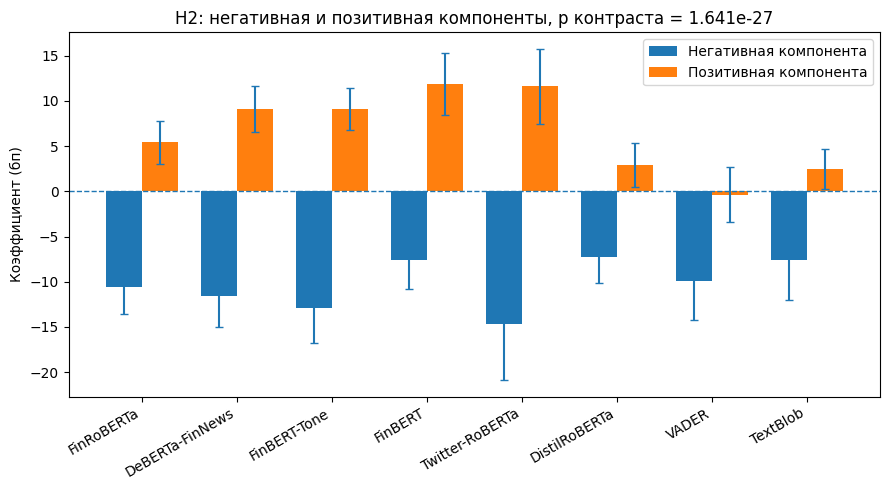

Сохранено: outputs_01/analysis_03_2/fig_H2_neg_vs_pos_coefficients.png


In [23]:
fig_path = os.path.join(ANALYSIS_DIR, "fig_H2_neg_vs_pos_coefficients.png")
tmp = h2.sort_values("contrast_p_two_sided").copy()

plt.figure(figsize=(9, 5))
x = np.arange(len(tmp))
w = 0.38
plt.bar(x - w / 2, tmp["beta_neg"].values * 10000, width=w, label="Негативная компонента")
plt.bar(x + w / 2, tmp["beta_pos"].values * 10000, width=w, label="Позитивная компонента")
plt.errorbar(x - w / 2, tmp["beta_neg"].values * 10000, yerr=1.96 * tmp["se_neg"].values * 10000, fmt="none", capsize=3)
plt.errorbar(x + w / 2, tmp["beta_pos"].values * 10000, yerr=1.96 * tmp["se_pos"].values * 10000, fmt="none", capsize=3)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(x, model_display_series(tmp["model"]), rotation=30, ha="right")
plt.ylabel("Коэффициент (бп)")
main_p = float(tmp.loc[tmp["model"] == MAIN_MODEL, "contrast_p_two_sided"].iloc[0]) if (tmp["model"] == MAIN_MODEL).any() else np.nan
plt.title(f"H2: негативная и позитивная компоненты, p контраста = {main_p:.4g}")
plt.legend()
plt.tight_layout()
plt.savefig(fig_path, dpi=170, bbox_inches="tight")
plt.show()
print("Сохранено:", fig_path)